In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle
import shap
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../../Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv'

data = read_data(path)
data.head()

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 
months: 7, 8, 9, 10, 11, 
years: 2022, 


,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.701364,12.274545,7.128182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.201406,0.201406,0.201406,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071,31,99,36,99.0,30,99,12,12,1,6,7,2,0,12,0,0
1,22.07722,41.01522,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.57952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.994259,10.090000,5.898519,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,0.096034,0.096034,0.096034,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432,31,94,36,95.0,30,94,12,12,3,5,8,2,0,11,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,15,0,0
3,23.95900,40.91196,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.41120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.262667,12.496667,8.028667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,0.036767,0.036767,0.036767,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784,31,93,36,93.0,30,93,12,12,3,5,8,2,0,4,0,0
4,23.69747,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.92004,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.1328,0.032298,-0.1328,0.018865,0.020253,0.039362,0.020253,11.778056,15.171111,8.385000,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,1.425578,1.425578,1.425578,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,13,0,0


In [4]:
data.query('month >= 5 & month <= 10').shape

(6349, 69)

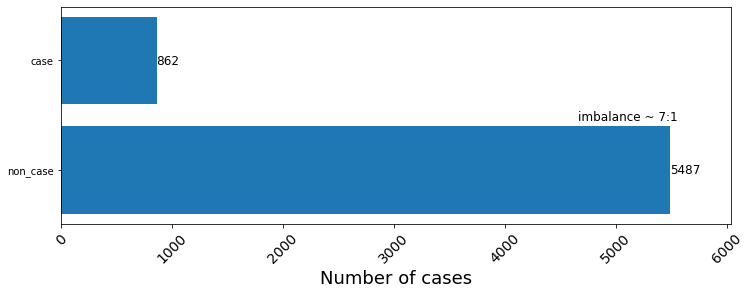

In [5]:
plot_imbalance(data.query('month >= 5 & month <= 10'))

In [6]:
dataset = data.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,478.8,38293.0,86.8,46.40326,0.277884,0.135286,-0.119594,-0.135286,0.289617,0.144593,-0.120979,-0.144593,0.033875,0.026132,0.013320,0.026132,23.797273,34.776364,12.818182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.849520,45.860931,513.316999,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071,31,99,36,99.0,30,99,12,12,1,6,7,2,0,1,84,0
1,22.07722,41.01522,2010-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,985.8,24924.0,28.0,46.57952,0.452498,0.135039,-0.276990,-0.135039,0.445984,0.140292,-0.264097,-0.140292,0.048772,0.040999,0.041759,0.040999,16.598704,23.051111,10.146296,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,13.010832,79.418586,556.232491,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432,31,94,36,95.0,30,94,12,12,3,5,8,2,0,17,222,0
2,22.89198,40.65603,2010-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,9.8,49674.0,5319.1,46.65786,0.170802,0.062868,-0.101038,-0.062868,0.166419,0.052195,-0.123815,-0.052195,0.085079,0.060522,0.023502,0.060522,22.320000,30.450000,14.190000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,3.478170,46.557858,498.499728,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,6,133,0
3,23.95900,40.91196,2010-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,411.8,7169.0,22.3,47.41120,0.520024,0.242873,-0.253985,-0.242873,0.518081,0.244385,-0.249705,-0.244385,0.043771,0.051783,0.033458,0.051783,18.250000,25.719333,10.780667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,4.135710,17.931808,570.517413,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784,31,93,36,93.0,30,93,12,12,3,5,8,2,0,26,88,0
4,23.69747,40.49593,2010-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,747.0,16994.0,24.5,46.92004,0.609696,0.317190,-0.243338,-0.317190,0.612239,0.315245,-0.246933,-0.315245,0.039368,0.041644,0.042532,0.041644,16.137222,21.571111,10.703333,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,9.678622,35.371020,502.368716,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,36,138,0


In [7]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment',
       'lc_prop2', 'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment',
       'lc_type1', 'lc_type2', 'lc_type3', 'lc

In [8]:
print(f'LAU1 Units: {dataset.lau1.unique().shape[0]}')

LAU1 Units: 38


In [9]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,367,250,617,9.72%
1,2011,432,31,463,7.29%
2,2012,437,20,457,7.20%
3,2013,439,21,460,7.25%
4,2014,456,0,456,7.18%
5,2015,456,0,456,7.18%
6,2016,456,0,456,7.18%
7,2017,456,0,456,7.18%
8,2018,387,117,504,7.94%
9,2019,420,53,473,7.45%


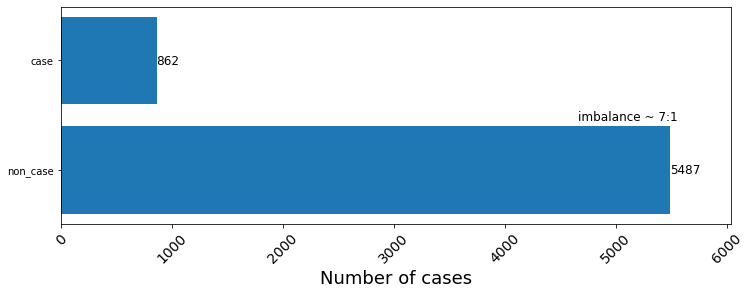

In [10]:
plot_imbalance(dataset)

In [11]:
majority_class = 0
near_u = 0
smote = 0
scaler = 'minmax'
weight_multiplier = 1
years_to_remove = [2014, 2015, 2016, 2017]
#years_to_remove = []

features_to_remove = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 
                      'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 
                      'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5','lw', 'qc',]

#features_to_remove = []

In [12]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                        + features_to_remove).columns

print(feature_names)

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')


In [13]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler, majority_class, features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:6 || ##
Year: 2011 || w0:1, w1:4 || ##
Year: 2012 || w0:1, w1:4 || ##
Year: 2013 || w0:1, w1:4 || ##
Year: 2014 || w0:1, w1:5 || ##
Year: 2015 || w0:1, w1:5 || ##
Year: 2016 || w0:1, w1:5 || ##
Year: 2017 || w0:1, w1:5 || ##
Year: 2018 || w0:1, w1:5 || ##
Year: 2019 || w0:1, w1:5 || ##
Year: 2020 || w0:1, w1:5 || ##
Year: 2021 || w0:1, w1:4 || ##
Year: 2022 || w0:1, w1:6 || ##


In [14]:
feature_names

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')

In [15]:
len(feature_names)

48

In [42]:
indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi',
            'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
            'ndvi_std','ndmi_std', 'ndwi_std', 'ndbi_std',]

weather = ['lst', 'lst_day', 'lst_night',
               'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
               'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
               'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',]

demographic = ['area', 'population', 'population_density',]

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',]

spatiotemporal = ['month_sin', 'month_cos', 'week_sin', 'week_cos','eq_distance',]

entomological = ['mosq_pred', 'mosq_previous']

In [43]:
len(indicies+weather+demographic+geomorphological+spatiotemporal+entomological)

48

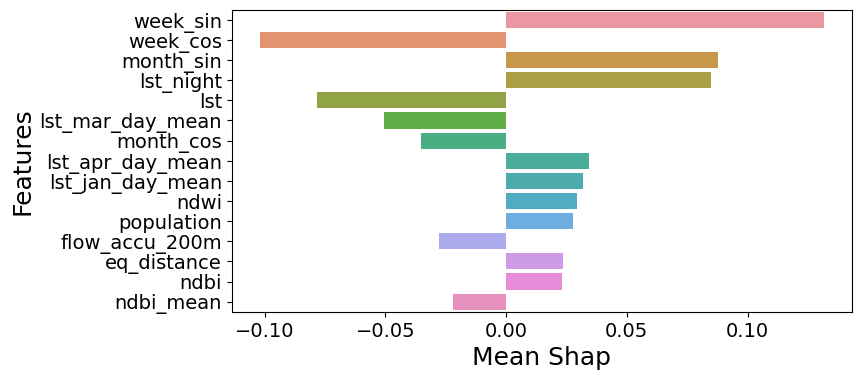

In [18]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

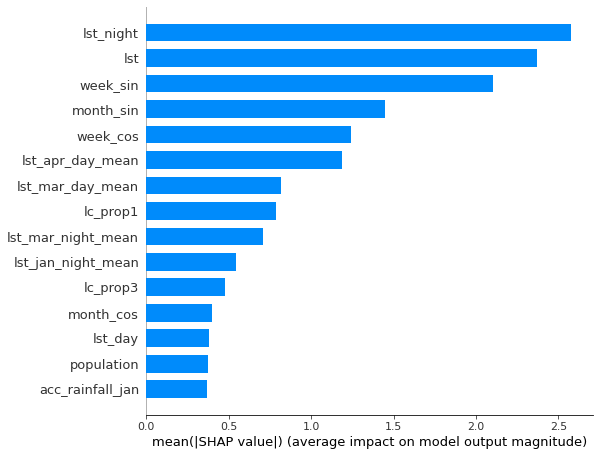

In [19]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

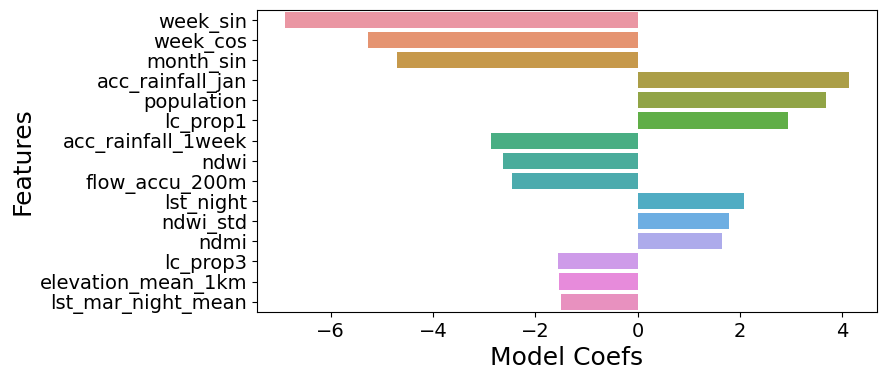

In [20]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

In [21]:
coefs

,features,weights
2,week_sin,-6.892630
3,week_cos,-5.270360
0,month_sin,-4.706707
33,acc_rainfall_jan,4.123215
5,population,3.674088
42,lc_prop1,2.931440
31,acc_rainfall_1week,-2.866967
10,ndwi,-2.640850
41,flow_accu_200m,-2.459733
22,lst_night,2.071568


In [22]:
shaps

,features,weights,weights_abs
2,week_sin,0.131514,0.131514
3,week_cos,-0.101923,0.101923
0,month_sin,0.087811,0.087811
22,lst_night,0.085047,0.085047
20,lst,-0.078286,0.078286
27,lst_mar_day_mean,-0.050440,0.050440
1,month_cos,-0.035127,0.035127
29,lst_apr_day_mean,0.034173,0.034173
23,lst_jan_day_mean,0.031882,0.031882
10,ndwi,0.029576,0.029576


,features,weights
4,spatiotemporal,0.076024
1,weather,0.028705
2,demographic,0.013045
0,rs_indicies,0.009658
3,geomorphological,0.007924
5,entomological,0.003231


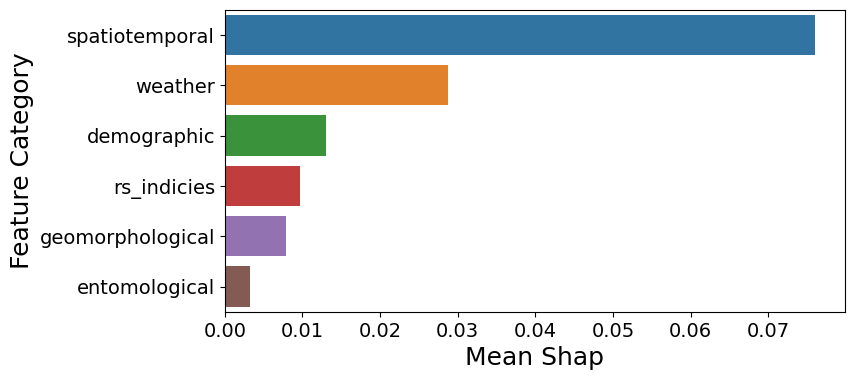

In [44]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_entomological = shaps.loc[shaps['features'].isin(entomological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 'demographic', 'geomorphological', 'spatiotemporal', 'entomological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_entomological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,6)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

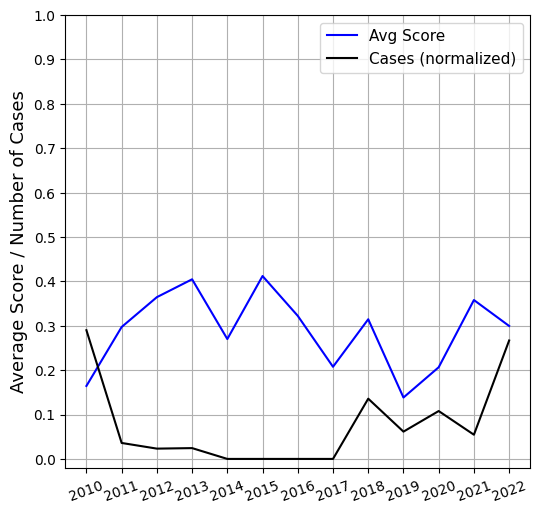

In [24]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

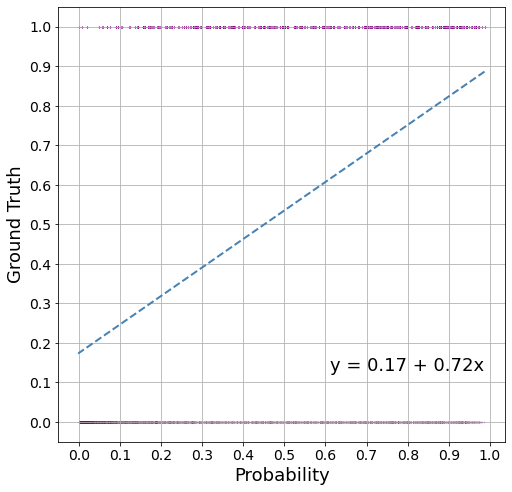

(0.17441922926336897, 0.7214901344861934)

In [25]:
plot_probability_curve(results_test)

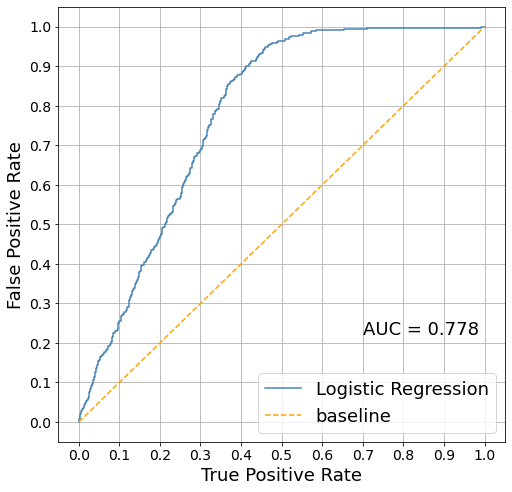

(0.3678, 0.8549, 0.2774, 0.7352)

In [39]:
plot_roc_curve(results_test, plot_gmean=False)

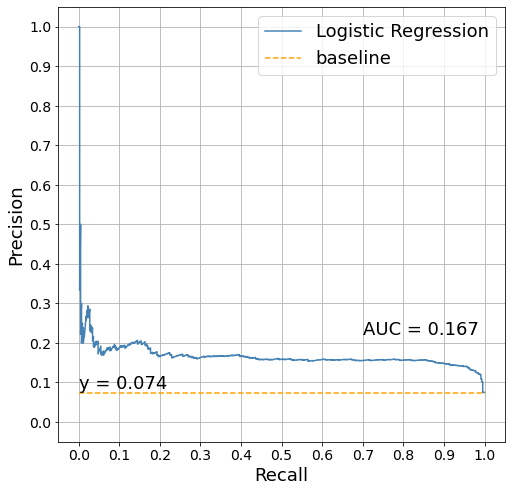

(0.8549, 0.16, 0.28, 0.4532)

In [40]:
plot_pr_curve(results_test, plot_fbeta = False)

In [28]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 44.05%
Weighted Average: 48.82%

Random Average: 23.93%
Random Weighted Average: 30.84%


In [29]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/05/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/05/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
3,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
4,01/07/2010,1,0,0.08,1,0.00 %,0.0,8.00 %,0.080
...,...,...,...,...,...,...,...,...,...
151,16/08/2022,23,4,3.02,5,80.00 %,0.8,60.40 %,0.604
152,01/09/2022,27,4,3.77,5,80.00 %,0.8,75.40 %,0.754
153,16/09/2022,22,3,3.01,5,60.00 %,0.6,60.20 %,0.602
154,01/10/2022,11,1,1.52,5,20.00 %,0.2,30.40 %,0.304


In [30]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,89,18,11.53,26,69.23 %,0.6923,44.35 %,0.4435
1,2011,24,8,3.38,20,40.00 %,0.4000,16.90 %,0.1690
2,2012,19,3,2.52,19,15.79 %,0.1579,13.26 %,0.1326
3,2013,17,7,2.06,17,41.18 %,0.4118,12.12 %,0.1212
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,69,18,9.37,34,52.94 %,0.5294,27.56 %,0.2756
9,2019,36,9,4.61,24,37.50 %,0.3750,19.21 %,0.1921


In [31]:
report_train, report_test = classification_report_new(results_train, results_test, threshold = 0.2, beta = 4)

In [32]:
report_train

,Accuracy,Precision,Recall,F4 Score,Loss
0,0.7816,0.2222,0.9735,0.812,0.395


In [33]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0000,0.2961,0.8605,0.5778,0.8764,0.8505,0.2694
1,2011,24.0000,0.5000,0.7419,0.1009,0.9583,0.6389,0.4379
2,2012,19.0000,0.5439,0.7380,0.0766,1.0000,0.5851,0.6593
3,2013,17.0000,0.5680,0.7244,0.0656,1.0000,0.5443,0.7839
4,2014,0.0000,0.4518,0.5482,0.0000,0.0000,0.0000,0.4420
5,2015,0.0000,0.5943,0.4057,0.0000,0.0000,0.0000,0.8452
6,2016,0.0000,0.4693,0.5307,0.0000,0.0000,0.0000,0.6487
7,2017,0.0000,0.3596,0.6404,0.0000,0.0000,0.0000,0.3332
8,2018,69.0000,0.4693,0.7785,0.3037,0.9420,0.8384,0.4704
9,2019,36.0000,0.2478,0.7425,0.2212,0.6944,0.6168,0.2486


In [34]:
results_test

,lau1,day,month,year,case,score
0,πελλας,16,8,2013,1,9.868526e-01
1,πελλας,1,8,2013,0,9.846215e-01
2,πελλας,16,8,2016,0,9.804842e-01
3,πελλας,1,9,2013,1,9.802200e-01
4,δελτα,1,7,2018,0,9.786527e-01
...,...,...,...,...,...,...
5923,ναουσας,16,10,2020,0,7.146310e-15
5924,νεαπολης συκεων,16,10,2020,0,5.356821e-15
5925,νεας ζιχνης,16,10,2020,0,5.125671e-15
5926,αμφιπολης,16,10,2020,0,4.517376e-15


In [35]:
results_test[['lau1', 'day', 'month', 'year']].value_counts()

lau1              day  month  year
αλεξανδρειας      1    5      2010    1
νεας προποντιδας  1    8      2019    1
                       9      2015    1
                              2014    1
                              2013    1
                                     ..
ηρακλειας         16   6      2021    1
                              2020    1
                              2019    1
                              2018    1
ωραιοκαστρου      16   10     2022    1
Length: 5928, dtype: int64

In [36]:
# results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [37]:
data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

object_cols = data_train.select_dtypes(include=['object']).columns.to_list()
removed_cols = features_to_remove

X_train = data_train.drop(columns = ['case'] + object_cols + removed_cols)
y_train = data_train['case']

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
           
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_value_counts = y_train.value_counts()
class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        
if (near_u != 0):
    if majority_class == 0:
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    elif majority_class == 1:
        nm = NearMiss(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 - near_u))}, version = 1, n_jobs = -1)

    X_train_resampled, y_train_resampled = nm.fit_resample(X_train_imputed, y_train)

    y_train_value_counts = y_train_resampled.value_counts()
    class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
    class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        

if (smote != 0):
    if majority_class == 0:
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    elif majority_class == 1:
        sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(class_0_counts * (1 + smote)), 1: class_1_counts}, n_jobs = -1, random_state = 0)

    if (near_u != 0):
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_resampled, y_train_resampled)
    else:
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)

X_train_returned = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
y_train_returned = y_train if (near_u == 0 and smote == 0) else y_train_resampled

value_counts = y_train_returned.value_counts()
non_cases = value_counts.get(key = 0) if value_counts.get(key = 0) is not None else 0
cases = value_counts.get(key = 1) if value_counts.get(key = 1) is not None else 0
        
if non_cases >= cases:
    w0 = 1
    try:
        w1 = math.ceil(non_cases/cases)
    except ZeroDivisionError:
        w1 = 10
else:
    w1 = 1
    try:
        w0 = math.ceil(cases/non_cases)
    except ZeroDivisionError:
        w0 = 10
            
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

model.fit(X_train_returned, y_train_returned)

model

LogisticRegression(class_weight={0.0: 1, 1.0: 5}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [38]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model_new.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer_new.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler_new.pkl', 'wb'))